In [1]:
# Project setup
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Project root: notebooks/ -> project root
PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
SRC_DIR = PROJECT_ROOT / "src"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
SRC_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Project root:", PROJECT_ROOT)
print("Raw data directory:", RAW_DIR)
print("Processed data directory:", PROCESSED_DIR)
print("Source directory:", SRC_DIR)


Project root: C:\Users\Lum-neh Angela\Documents\Data\CreditScoring_Kaggle
Raw data directory: C:\Users\Lum-neh Angela\Documents\Data\CreditScoring_Kaggle\data\raw
Processed data directory: C:\Users\Lum-neh Angela\Documents\Data\CreditScoring_Kaggle\data\processed
Source directory: C:\Users\Lum-neh Angela\Documents\Data\CreditScoring_Kaggle\src


In [2]:
# Load raw training data
train_df = pd.read_csv(RAW_DIR / "train.csv")
train_df.head()


<ipython-input-2-7349d10eca59>:2: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv(RAW_DIR / "train.csv")


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.0,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.0,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,_,4.0,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4,6.27,4.0,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.0,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [3]:
train_df.shape

(100000, 28)

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [5]:
train_df.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


In [6]:
# Summary for categorical columns
train_df.describe(include='object')

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Num_of_Loan,Type_of_Loan,Num_of_Delayed_Payment,Changed_Credit_Limit,Credit_Mix,Outstanding_Debt,Credit_History_Age,Payment_of_Min_Amount,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,100000,100000,100000,90015,100000,100000,100000,100000,100000,88592,92998,100000,100000,100000,90970,100000,95521,100000,98800,100000
unique,100000,12500,8,10139,1788,12501,16,18940,434,6260,749,4384,4,13178,404,3,91049,7,98792,3
top,0x1602,CUS_0xd40,January,Langep,38,#F%$D@*&8,_______,36585.12,3,Not Specified,19,_,Standard,1360.45,15 Years and 11 Months,Yes,__10000__,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
freq,1,8,12500,44,2833,5572,7062,16,14386,1408,5327,2091,36479,24,446,52326,4305,25513,9,53174


#### Check for missing values

In [7]:
train_df.isnull().sum()

ID                              0
Customer_ID                     0
Month                           0
Name                         9985
Age                             0
SSN                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary       15002
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Type_of_Loan                11408
Delay_from_due_date             0
Num_of_Delayed_Payment       7002
Changed_Credit_Limit            0
Num_Credit_Inquiries         1965
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age           9030
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      4479
Payment_Behaviour               0
Monthly_Balance              1200
Credit_Score                    0
dtype: int64

In [8]:
missing_values = train_df.isnull().sum()
missing_percent = (missing_values / len(train_df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_values,
    'Missing_Percentage': missing_percent
})
missing_df.sort_values(by='Missing_Percentage', ascending=False)

,Missing_Count,Missing_Percentage
Monthly_Inhand_Salary,15002,15.002
Type_of_Loan,11408,11.408
Name,9985,9.985
Credit_History_Age,9030,9.030
Num_of_Delayed_Payment,7002,7.002
Amount_invested_monthly,4479,4.479
Num_Credit_Inquiries,1965,1.965
Monthly_Balance,1200,1.200
ID,0,0.000
Changed_Credit_Limit,0,0.000


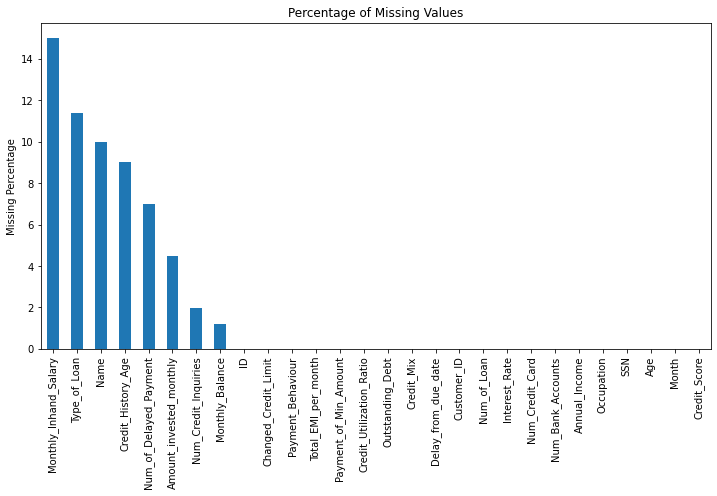

In [9]:
#Visualize Missing Values 
plt.figure(figsize=(12,6))
missing_df['Missing_Percentage'].sort_values(ascending=False).plot(kind='bar')
plt.title('Percentage of Missing Values')
plt.ylabel('Missing Percentage')
plt.xticks(rotation=90)
plt.show()

#### Check for duplicates

In [10]:
train_df.duplicated().sum()

0

In [11]:
train_df["ID"].duplicated().sum()

0

In [12]:
train_df["Customer_ID"].duplicated().sum()

87500

#### Check the target distribution

In [13]:
train_df["Credit_Score"].value_counts()

Standard    53174
Poor        28998
Good        17828
Name: Credit_Score, dtype: int64

In [14]:
train_df["Credit_Score"].value_counts(normalize=True).mul(100).round(2)

Standard    53.17
Poor        29.00
Good        17.83
Name: Credit_Score, dtype: float64

#### Check customer Structure

In [15]:
train_df["Customer_ID"].nunique()

12500

In [16]:
train_df["Customer_ID"].value_counts().describe()

count    12500.0
mean         8.0
std          0.0
min          8.0
25%          8.0
50%          8.0
75%          8.0
max          8.0
Name: Customer_ID, dtype: float64

In [17]:
train_df["Customer_ID"].value_counts().head(10)

CUS_0xd40     8
CUS_0x9bf4    8
CUS_0x5ae3    8
CUS_0xbe9a    8
CUS_0x4874    8
CUS_0xc67b    8
CUS_0x8a64    8
CUS_0x35ea    8
CUS_0x5044    8
CUS_0x9dfd    8
Name: Customer_ID, dtype: int64

#### Identify Suspicious Datatypes

In [18]:
train_df.dtypes.to_frame("dtype")

,dtype
ID,object
Customer_ID,object
Month,object
Name,object
Age,object
SSN,object
Occupation,object
Annual_Income,object
Monthly_Inhand_Salary,float64
Num_Bank_Accounts,int64


In [19]:
numeric_like = [
    "Age",
    "Annual_Income",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Outstanding_Debt",
    "Amount_invested_monthly",
    "Monthly_Balance"
]

for col in numeric_like:
    print(f"\n{'='*60}")
    print(col)
    print(train_df[col].dropna().astype(str).head(10).tolist())


Age
['23', '23', '-500', '23', '23', '23', '23', '23', '28_', '28']

Annual_Income
['19114.12', '19114.12', '19114.12', '19114.12', '19114.12', '19114.12', '19114.12', '19114.12', '34847.84', '34847.84']

Num_of_Loan
['4', '4', '4', '4', '4', '4', '4', '4', '1', '1']

Num_of_Delayed_Payment
['7', '7', '4', '4', '8_', '6', '4', '1', '-1', '3_']

Changed_Credit_Limit
['11.27', '11.27', '_', '6.27', '11.27', '9.27', '11.27', '11.27', '5.42', '7.42']

Outstanding_Debt
['809.98', '809.98', '809.98', '809.98', '809.98', '809.98', '809.98', '809.98', '605.03', '605.03']

Amount_invested_monthly
['80.41529543900253', '118.28022162236736', '81.699521264648', '199.4580743910713', '41.420153086217326', '62.430172331195294', '178.3440674122349', '24.785216509052056', '104.291825168246', '40.39123782853101']

Monthly_Balance
['312.49408867943663', '284.62916249607184', '331.2098628537912', '223.45130972736786', '341.48923103222177', '340.4792117872438', '244.5653167062043', '358.12416760938714', '

In [20]:
categorical_candidates = [
    "Month",
    "Occupation",
    "Type_of_Loan",
    "Credit_Mix",
    "Payment_of_Min_Amount",
    "Payment_Behaviour"
]

for col in categorical_candidates:
    print(f"\n{col}")
    print(train_df[col].nunique(dropna=True))
    print(train_df[col].dropna().unique()[:20])


Month
8
['January' 'February' 'March' 'April' 'May' 'June' 'July' 'August']

Occupation
16
['Scientist' '_______' 'Teacher' 'Engineer' 'Entrepreneur' 'Developer'
 'Lawyer' 'Media_Manager' 'Doctor' 'Journalist' 'Manager' 'Accountant'
 'Musician' 'Mechanic' 'Writer' 'Architect']

Type_of_Loan
6260
['Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan'
 'Credit-Builder Loan' 'Auto Loan, Auto Loan, and Not Specified'
 'Not Specified' 'Credit-Builder Loan, and Mortgage Loan'
 'Not Specified, Auto Loan, and Student Loan'
 'Personal Loan, Debt Consolidation Loan, and Auto Loan'
 'Not Specified, and Payday Loan'
 'Credit-Builder Loan, Personal Loan, and Auto Loan'
 'Payday Loan, and Payday Loan'
 'Not Specified, Student Loan, and Personal Loan'
 'Personal Loan, Payday Loan, Student Loan, Auto Loan, Home Equity Loan, Student Loan, and Payday Loan'
 'Not Specified, Student Loan, Student Loan, Credit-Builder Loan, and Auto Loan'
 'Payday Loan, and Home Equity Loan'
 'Credit-Build

In [21]:
# Check if a customer's credit score chnages over time
customer_score_counts = (train_df.groupby("Customer_ID")["Credit_Score"].nunique())

customer_score_counts.value_counts().sort_index()

1    5208
2    7262
3      30
Name: Credit_Score, dtype: int64

In [22]:
# Check target distribution by month
pd.crosstab(
    train_df["Month"],
    train_df["Credit_Score"],
    normalize="index"
).round(3)

Credit_Score,Good,Poor,Standard
Month,,,
April,0.189,0.294,0.518
August,0.193,0.288,0.519
February,0.161,0.283,0.556
January,0.158,0.287,0.555
July,0.193,0.289,0.518
June,0.189,0.298,0.513
March,0.159,0.284,0.557
May,0.185,0.297,0.518


In [23]:
# check whether the target is associated with customer history
pd.crosstab(
    train_df["Customer_ID"],
    train_df["Credit_Score"]
).head(10)

Credit_Score,Good,Poor,Standard
Customer_ID,,,
CUS_0x1000,0,7,1
CUS_0x1009,0,0,8
CUS_0x100b,0,5,3
CUS_0x1011,0,0,8
CUS_0x1013,0,0,8
CUS_0x1015,5,0,3
CUS_0x1018,0,8,0
CUS_0x1026,0,0,8
CUS_0x102d,8,0,0


In [24]:
# Check records neding _ cleanup
numeric_like = [
    "Age",
    "Annual_Income",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Outstanding_Debt",
    "Amount_invested_monthly",
    "Monthly_Balance"
]

for col in numeric_like:
    values = train_df[col].astype(str)

    print(f"\n{'='*60}")
    print(col)
    print("Contains '_':", values.str.contains("_", regex=False).sum())


Age
Contains '_': 4939

Annual_Income
Contains '_': 6980

Num_of_Loan
Contains '_': 4785

Num_of_Delayed_Payment
Contains '_': 2744

Changed_Credit_Limit
Contains '_': 2091

Outstanding_Debt
Contains '_': 1009

Amount_invested_monthly
Contains '_': 4305

Monthly_Balance
Contains '_': 9


In [25]:
# check the various invalid age types
age_numeric = pd.to_numeric(
    train_df["Age"].astype(str).str.replace("_", "", regex=False),
    errors="coerce"
)

print(age_numeric.describe())

print("\nInvalid ages:")
print((age_numeric <= 0).sum())

print("\nAges > 100:")
print((age_numeric > 100).sum())

count    100000.000000
mean        110.649700
std         686.244717
min        -500.000000
25%          24.000000
50%          33.000000
75%          42.000000
max        8698.000000
Name: Age, dtype: float64

Invalid ages:
886

Ages > 100:
1890


In [26]:
for col in [
    "Annual_Income",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Interest_Rate",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Delay_from_due_date",
    "Num_Credit_Inquiries",
    "Outstanding_Debt",
    "Credit_Utilization_Ratio",
    "Total_EMI_per_month"
]:
    values = pd.to_numeric(
        train_df[col].astype(str).str.replace("_", "", regex=False),
        errors="coerce"
    )

    print(f"\n{col}")
    print(values.describe()[["min", "25%", "50%", "75%", "max"]])


Annual_Income
min        7005.93
25%       19457.50
50%       37578.61
75%       72790.92
max    24198062.00
Name: Annual_Income, dtype: float64

Num_Bank_Accounts
min      -1.0
25%       3.0
50%       6.0
75%       7.0
max    1798.0
Name: Num_Bank_Accounts, dtype: float64

Num_Credit_Card
min       0.0
25%       4.0
50%       5.0
75%       7.0
max    1499.0
Name: Num_Credit_Card, dtype: float64

Interest_Rate
min       1.0
25%       8.0
50%      13.0
75%      20.0
max    5797.0
Name: Interest_Rate, dtype: float64

Num_of_Loan
min    -100.0
25%       1.0
50%       3.0
75%       5.0
max    1496.0
Name: Num_of_Loan, dtype: float64

Num_of_Delayed_Payment
min      -3.0
25%       9.0
50%      14.0
75%      18.0
max    4397.0
Name: Num_of_Delayed_Payment, dtype: float64

Delay_from_due_date
min    -5.0
25%    10.0
50%    18.0
75%    28.0
max    67.0
Name: Delay_from_due_date, dtype: float64

Num_Credit_Inquiries
min       0.0
25%       3.0
50%       6.0
75%       9.0
max    2597.0
Name: Nu

### Numeric Variable Distribution

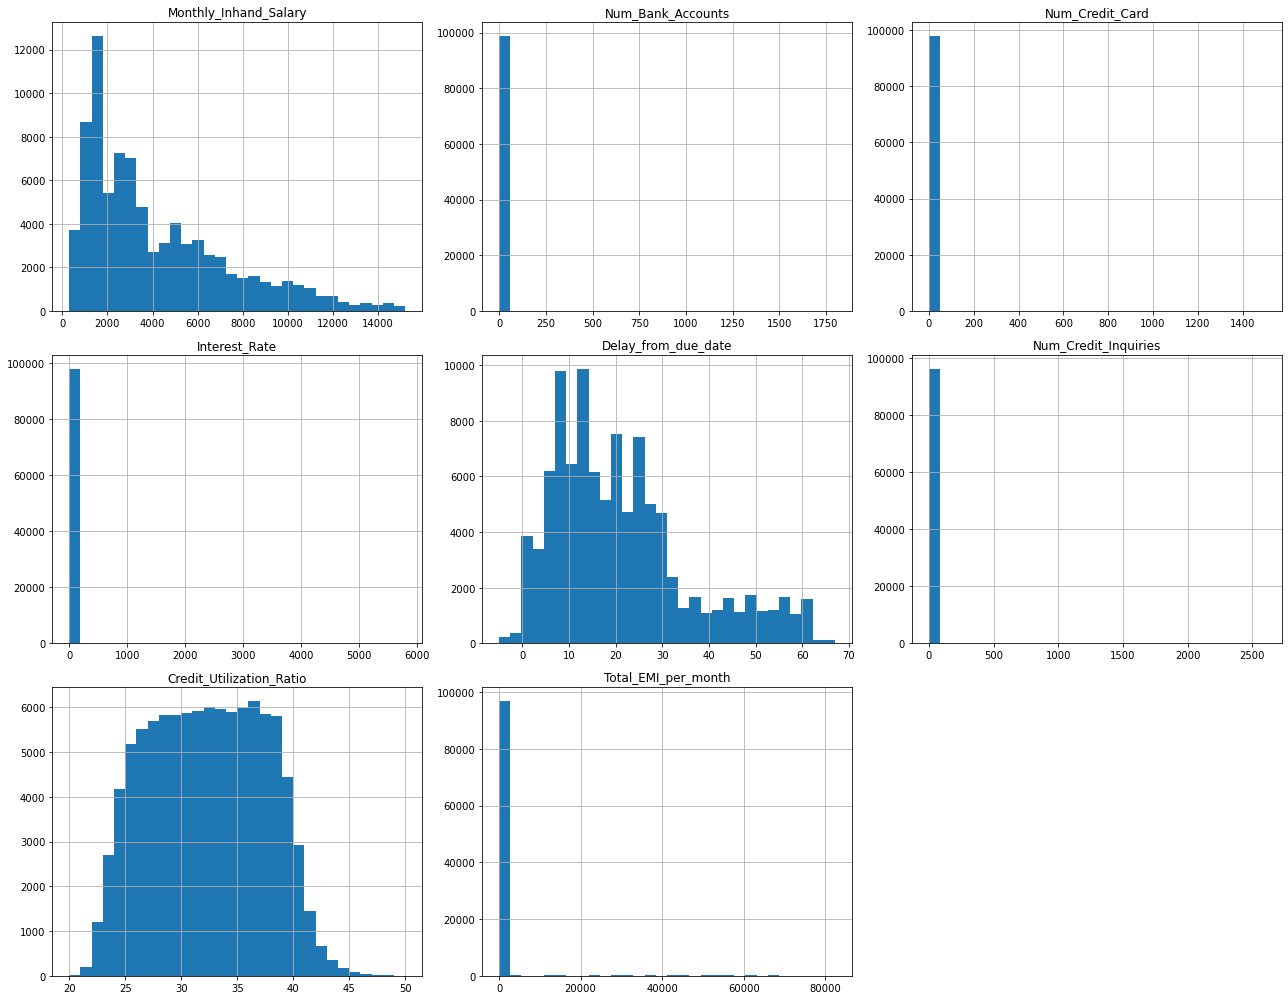

In [27]:
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns

train_df[numeric_cols].hist(figsize=(18,14), bins=30)
plt.tight_layout()
plt.show()

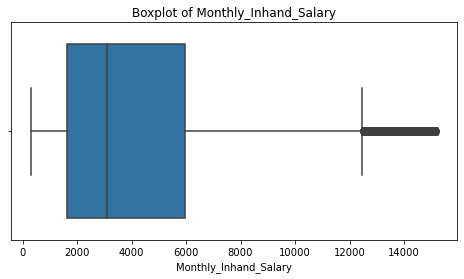

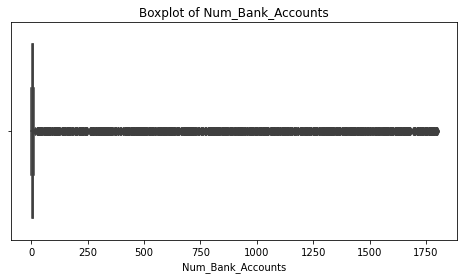

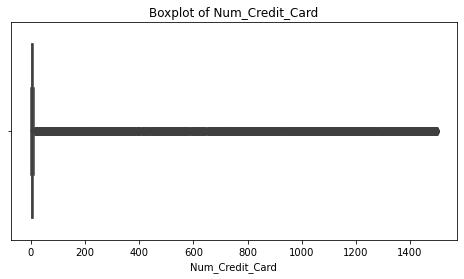

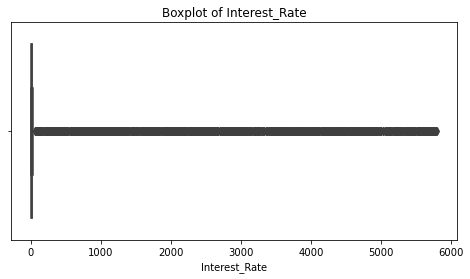

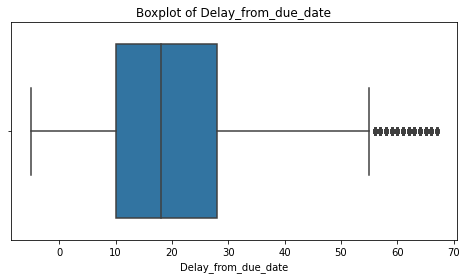

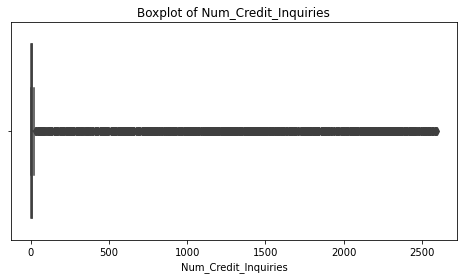

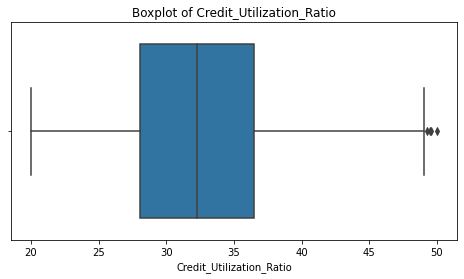

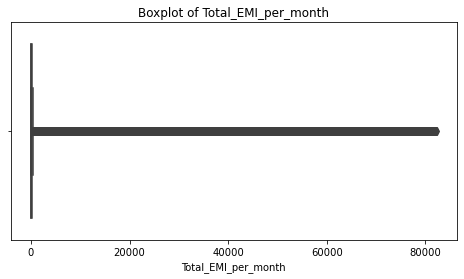

In [28]:
# Outlier Detection for numerical variables. Outliers detected for Monthly_inhand_salary,Delay_from_due_date,
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=train_df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

### Data Preprocessing

In [29]:
%%writefile ../src/preprocessing.py

import pandas as pd
import numpy as np


NUMERIC_COLUMNS = [
    "Age",
    "Annual_Income",
    "Monthly_Inhand_Salary",
    "Num_Bank_Accounts",
    "Num_Credit_Card",
    "Interest_Rate",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Num_Credit_Inquiries",
    "Delay_from_due_date",
    "Outstanding_Debt",
    "Credit_Utilization_Ratio",
    "Total_EMI_per_month",
    "Amount_invested_monthly",
    "Monthly_Balance",
]


def clean_numeric_columns(df):
    df = df.copy()

    for col in NUMERIC_COLUMNS:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.replace("_", "", regex=False)
                .str.strip()
            )

            df[col] = pd.to_numeric(
                df[col],
                errors="coerce"
            )

    return df


def clean_categorical_columns(df):
    df = df.copy()

    df["Occupation"] = df["Occupation"].replace(
        "_______",
        np.nan
    )

    df["Credit_Mix"] = df["Credit_Mix"].replace(
        "_",
        np.nan
    )

    df["Payment_Behaviour"] = df["Payment_Behaviour"].replace(
        "!@9#%8",
        np.nan
    )

    return df


def clean_age(df):
    df = df.copy()

    df["Age"] = pd.to_numeric(
        df["Age"],
        errors="coerce"
    )

    df.loc[
        (df["Age"] < 18) | (df["Age"] > 100),
        "Age"
    ] = np.nan

    return df


def convert_credit_history_age(df):
    df = df.copy()

    pattern = (
        r"(?P<years>\d+)\s+Years?\s+and\s+"
        r"(?P<months>\d+)\s+Months?"
    )

    extracted = df["Credit_History_Age"].str.extract(pattern)

    df["Credit_History_Months"] = (
        pd.to_numeric(extracted["years"], errors="coerce") * 12
        + pd.to_numeric(extracted["months"], errors="coerce")
    )

    df = df.drop(columns=["Credit_History_Age"])

    return df


def engineer_loan_features(df):
    df = df.copy()

    loan_col = df["Type_of_Loan"].fillna("")

    df["Num_Loan_Types"] = loan_col.apply(
        lambda x: 0 if x == "" else len(
            [loan.strip() for loan in x.split(",")]
        )
    )

    loan_types = [
        "Auto Loan",
        "Credit-Builder Loan",
        "Personal Loan",
        "Home Equity Loan",
        "Mortgage Loan",
        "Student Loan",
        "Debt Consolidation Loan",
        "Payday Loan",
    ]

    for loan_type in loan_types:
        feature_name = (
            "Has_"
            + loan_type.lower()
            .replace(" ", "_")
            .replace("-", "_")
        )

        df[feature_name] = (
            loan_col
            .str.contains(
                loan_type,
                case=False,
                regex=False
            )
            .astype(int)
        )

    df = df.drop(columns=["Type_of_Loan"])

    return df


def clean_raw_data(df):
    df = df.copy()

    df = clean_numeric_columns(df)
    df = clean_categorical_columns(df)
    df = clean_age(df)
    df = convert_credit_history_age(df)
    df = engineer_loan_features(df)

    return df

Overwriting ../src/preprocessing.py


In [30]:
# Import the reusable cleaning function
from src.preprocessing import clean_raw_data


In [31]:
# Create the cleaned dataset
clean_df = clean_raw_data(train_df)

print("Cleaned dataset shape:", clean_df.shape)
clean_df.head()


Cleaned dataset shape: (100000, 36)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Credit_History_Months,Num_Loan_Types,Has_auto_loan,Has_credit_builder_loan,Has_personal_loan,Has_home_equity_loan,Has_mortgage_loan,Has_student_loan,Has_debt_consolidation_loan,Has_payday_loan
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,3,7.0,11.27,4.0,NaN,809.98,26.822620,No,49.574949,80.415295,High_spent_Small_value_payments,312.494089,Good,265.0,4,1,1,1,1,0,0,0,0
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,-1,NaN,11.27,4.0,Good,809.98,31.944960,No,49.574949,118.280222,Low_spent_Large_value_payments,284.629162,Good,NaN,4,1,1,1,1,0,0,0,0
2,0x1604,CUS_0xd40,March,Aaron Maashoh,NaN,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,3,7.0,NaN,4.0,Good,809.98,28.609352,No,49.574949,81.699521,Low_spent_Medium_value_payments,331.209863,Good,267.0,4,1,1,1,1,0,0,0,0
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,5,4.0,6.27,4.0,Good,809.98,31.377862,No,49.574949,199.458074,Low_spent_Small_value_payments,223.451310,Good,268.0,4,1,1,1,1,0,0,0,0
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23.0,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,6,NaN,11.27,4.0,Good,809.98,24.797347,No,49.574949,41.420153,High_spent_Medium_value_payments,341.489231,Good,269.0,4,1,1,1,1,0,0,0,0


In [32]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 36 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   ID                           100000 non-null  object 
 1   Customer_ID                  100000 non-null  object 
 2   Month                        100000 non-null  object 
 3   Name                         90015 non-null   object 
 4   Age                          91518 non-null   float64
 5   SSN                          100000 non-null  object 
 6   Occupation                   92938 non-null   object 
 7   Annual_Income                100000 non-null  float64
 8   Monthly_Inhand_Salary        84998 non-null   float64
 9   Num_Bank_Accounts            100000 non-null  int64  
 10  Num_Credit_Card              100000 non-null  int64  
 11  Interest_Rate                100000 non-null  int64  
 12  Num_of_Loan                  100000 non-null  int64  
 13  

## Save Cleaned Dataset

Saving this artifact makes the next notebook independent of the in-memory state of this notebook.


In [33]:
clean_df_path = PROCESSED_DIR / "clean_df.pkl"

clean_df.to_pickle(clean_df_path)

print("Cleaned dataset saved successfully.")
print("Path:", clean_df_path)
print("Shape:", clean_df.shape)
print("Unique customers:", clean_df["Customer_ID"].nunique())


Cleaned dataset saved successfully.
Path: C:\Users\Lum-neh Angela\Documents\Data\CreditScoring_Kaggle\data\processed\clean_df.pkl
Shape: (100000, 36)
Unique customers: 12500
